# PTCG Scanner — full pipeline (PDF → OCR → catalog)

End-to-end, **no training**:

1. Read PDFs in `data/pdf` (each page becomes an image).
2. **Detection** finds each card; **cropper** warps to 63×88 mm.
3. **OCR** reads name, number, and set (when printed).
4. Look up the nearest card in `data/cards-list.csv` (setId from [PkmnCards](https://pkmncards.com/sets/)).
5. Check against the CSV next to the PDF (`Base.pdf` ↔ `Base.csv`).

Outputs go to `output/`: CSVs, plots, and per PDF `output/pdfs/<name>/` with each stage (`01_pages`, `02_obb`, `03_crops`, `04_ocr`, `05_match`).

The metrics cell scores **ROI coverage** (YOLO strip vs template), **OCR** (name/number accuracy + CER), and the **end-to-end** catalog funnel.

Run the cells in order. A GPU helps YOLO and EasyOCR.


In [25]:
from __future__ import annotations

import re
import shutil
import sys
import unicodedata
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymupdf
import torch
from IPython.display import display, update_display
from ultralytics import YOLO

def find_repo() -> Path:
    here = Path(".").resolve()
    for p in [here, *here.parents]:
        if (p / "src" / "cropper" / "rectify.py").is_file() and (p / "src" / "detection").is_dir():
            return p
    raise FileNotFoundError(
        "Open this notebook from the PTCG Scanner repo (folders src/cropper/ and src/detection/)."
    )


REPO = find_repo()

sys.path.insert(0, str(REPO / "src" / "cropper"))
sys.path.insert(0, str(REPO / "src" / "ocr"))

from crop_from_obb import DEFAULT_WEIGHTS, imgsz_for_weights
from rectify import crop_result
from read_card import read_card

DATA = REPO / "data"
PDF_DIR = DATA / "pdf"
CATALOG_CSV = DATA / "cards-list.csv"
SETS_CSV = DATA / "sets-id.csv"
OUT_DIR = REPO / "output"
OUT_PDF_DIR = OUT_DIR / "pdfs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PDF_DIR.mkdir(parents=True, exist_ok=True)

OBB_WEIGHTS = DEFAULT_WEIGHTS
OCR_WEIGHTS = REPO / "src" / "roi" / "runs" / "ocr-roi-v1" / "weights" / "ocr-roi-v1.pt"
CARD_CONF = 0.8
OCR_CONF = 0.4
PDF_DPI = 200
DEVICE = 0 if torch.cuda.is_available() else "cpu"
JPEG_QUALITY = 85
CROP_CELL = (372, 520)


def fold(text: str) -> str:
    text = unicodedata.normalize("NFKD", text or "")
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    return re.sub(r"[^a-z0-9]+", "", text.lower())


def parse_number(text: str) -> tuple[int | None, int | None]:
    match = re.search(r"(\d+)\s*/\s*(\d+)", text or "")
    if match:
        return int(match.group(1)), int(match.group(2))
    digits = re.sub(r"\D", "", text or "")
    if len(digits) >= 3:
        return int(digits[:3]), int(digits[3:]) if len(digits) > 3 else None
    return None, None


def format_number(collector: int | None, total: int | None) -> str:
    if collector is None:
        return ""
    if total is None:
        return str(collector)
    return f"{collector}/{total}"


print("Repo     :", REPO)
print("PDFs     :", PDF_DIR, "exists=", PDF_DIR.is_dir())
print("Catalog  :", CATALOG_CSV, "exists=", CATALOG_CSV.is_file())
print("Sets     :", SETS_CSV, "exists=", SETS_CSV.is_file())
print("Output   :", OUT_DIR)
print("OBB      :", OBB_WEIGHTS, "exists=", OBB_WEIGHTS.is_file())
print("OCR ROI  :", OCR_WEIGHTS, "exists=", OCR_WEIGHTS.is_file())
print("Device   :", DEVICE)


Repo     : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao
PDFs     : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\pdf exists= True
Catálogo : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\cards-list.csv exists= True
Sets     : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\sets-id.csv exists= True
Saída    : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output
OBB      : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\OBB\runs\obb\obb-v3\weights\obb-v3.pt exists= True
OCR ROI  : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\OCR\runs\ocr-roi-v1\weights\ocr-roi-v1.pt exists= True
Device   : 0


## 1. Catalog (`data/cards-list.csv`)

One row per card: `Name`, `Number`, `Rarity`, `setId` ([PkmnCards](https://pkmncards.com/sets/), e.g. `BS`, `MEW`, `ASR`). Set display names come from `data/sets-id.csv`.


In [26]:
def load_catalog(csv_path: Path, sets_path: Path) -> pd.DataFrame:
    raw = pd.read_csv(csv_path)
    cols = {c.lower(): c for c in raw.columns}
    if "name" not in cols or "number" not in cols or "setid" not in cols:
        raise ValueError(f"Catalog needs Name, Number, setId: {csv_path}")
    sets = pd.read_csv(sets_path)
    name_by_id = dict(zip(sets["id"].astype(str), sets["name"].astype(str)))
    rows = []
    for _, row in raw.iterrows():
        name = str(row[cols["name"]]).strip()
        number = str(row[cols["number"]]).strip()
        rarity = str(row[cols["rarity"]]).strip() if "rarity" in cols else ""
        set_id = str(row[cols["setid"]]).strip()
        collector, total = parse_number(number)
        rows.append(
            {
                "name": name,
                "number": number,
                "rarity": rarity,
                "set_id": set_id,
                "set_code": set_id,
                "set_name": name_by_id.get(set_id, set_id),
                "set_file": set_id,
                "collector": collector,
                "total": total,
                "name_fold": fold(name),
            }
        )
    catalog = pd.DataFrame(rows)
    catalog = catalog.drop_duplicates(subset=["name_fold", "number", "set_id"], keep="first")
    return catalog.reset_index(drop=True)


catalog = load_catalog(CATALOG_CSV, SETS_CSV)
print(f"{len(catalog):,} cartas em {catalog['set_id'].nunique()} sets")
print(catalog.sample(min(5, len(catalog)), random_state=0)[["name", "number", "set_id", "set_name"]])


20,202 cartas em 167 sets
                        name    number set_id              set_name
17502    Unidentified Fossil   165/195    SIT        Silver Tempest
772                  Pansage  BW11/101    BWP  BW Black Star Promos
1884                  Durant    92/135    PLS          Plasma Storm
17445             Skuntank V   108/195    SIT        Silver Tempest
12981  Misty's Determination     62/68    HIF          Hidden Fates


## 2. PDFs and ground truth (`data/pdf`)

Each PDF has a CSV with the same stem (`Base.pdf` ↔ `Base.csv`): `Name`, `Number`, `Rarity`, `setId`.


In [27]:
def load_pdf_jobs(pdf_dir: Path) -> list[dict]:
    jobs = []
    for pdf in sorted(pdf_dir.glob("*.pdf")):
        csv_path = pdf.with_suffix(".csv")
        set_id = ""
        if csv_path.is_file():
            frame = pd.read_csv(csv_path)
            cols = {c.lower(): c for c in frame.columns}
            if "setid" in cols and len(frame):
                set_id = str(frame[cols["setid"]].iloc[0]).strip()
        jobs.append({"pdf": pdf, "csv": csv_path, "set_id": set_id})
    return jobs


def load_truth(jobs: list[dict]) -> pd.DataFrame:
    rows = []
    for job in jobs:
        csv_path = job["csv"]
        if not csv_path.is_file():
            print("sem CSV de verdade:", job["pdf"].name)
            continue
        raw = pd.read_csv(csv_path)
        cols = {c.lower(): c for c in raw.columns}
        for _, row in raw.iterrows():
            number = str(row[cols["number"]]).strip() if "number" in cols else ""
            collector, total = parse_number(number)
            rows.append(
                {
                    "image": job["pdf"].name,
                    "name": str(row[cols["name"]]).strip() if "name" in cols else "",
                    "number": number,
                    "collection": str(row[cols["setid"]]).strip() if "setid" in cols else job["set_id"],
                    "collector": collector,
                    "total": total,
                }
            )
    return pd.DataFrame(rows)


pdf_jobs = load_pdf_jobs(PDF_DIR)
truth = load_truth(pdf_jobs)
print(f"{len(pdf_jobs)} PDF(s)  |  {len(truth)} carta(s) anotadas")
for job in pdf_jobs:
    print(f"  {job['pdf'].name}  setId={job['set_id'] or '—'}  csv={job['csv'].is_file()}")
display(truth.head(12))


9 PDF(s)  |  1616 carta(s) anotadas
  151.pdf  setId=MEW  csv=True
  Ascended Heroes.pdf  setId=ASC  csv=True
  Astral Radiance.pdf  setId=ASR  csv=True
  Base.pdf  setId=BS  csv=True
  BREAKpoint.pdf  setId=BKP  csv=True
  Delta Species.pdf  setId=DS  csv=True
  Diamond & Pearl.pdf  setId=DP  csv=True
  SM Black Star Promos.pdf  setId=SMP  csv=True
  Stellar Crown.pdf  setId=SCR  csv=True


,image,name,number,collection,collector,total
0,151.pdf,Bulbasaur,1/165,MEW,1,165
1,151.pdf,Ivysaur,2/165,MEW,2,165
2,151.pdf,Venusaur ex,3/165,MEW,3,165
3,151.pdf,Charmander,4/165,MEW,4,165
4,151.pdf,Charmeleon,5/165,MEW,5,165
5,151.pdf,Charizard ex,6/165,MEW,6,165
6,151.pdf,Squirtle,7/165,MEW,7,165
7,151.pdf,Wartortle,8/165,MEW,8,165
8,151.pdf,Blastoise ex,9/165,MEW,9,165
9,151.pdf,Caterpie,10/165,MEW,10,165


## 3. Nearest card in the catalog

Priority: **name**, then **number** (collector + set size), then **collection** (PDF setId or the code read on the card). English catalog names count as the same name as Portuguese OCR.


In [28]:
from difflib import SequenceMatcher

_STOPWORDS = {
    "de", "da", "do", "dos", "das", "e", "o", "a", "os", "as",
    "the", "of", "and", "s", "lv",
}
_WORD_EN = {
    "castelo": "castle",
    "espirito": "spirit",
    "luta": "fighting",
    "busca": "scouting",
    "bolsa": "bag",
    "faixa": "band",
    "escolha": "choice",
    "treino": "training",
    "perola": "pearl",
    "lilian": "lillie",
    "lillian": "lillie",
    "lilies": "lillie",
    "lupo": "hop",
    "vastro": "vstar",
    "preta": "black",
    "hisui": "hisuian",
}


def folded_words(text: str) -> list[str]:
    text = (text or "").replace("'s", " ").replace("’s", " ").replace(".", " ")
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch)).lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    words: list[str] = []
    for word in text.split():
        match = re.match(r"^(.+?)(vstar|vastro|vmax|ex|gx)$", word)
        if match and len(match.group(1)) >= 3:
            words.extend([match.group(1), match.group(2)])
        else:
            words.append(word)
    return words


def name_tokens(text: str) -> set[str]:
    tokens = set()
    for word in folded_words(text):
        if word in _STOPWORDS or len(word) <= 1:
            continue
        tokens.add(_WORD_EN.get(word, word))
    return tokens


def edit_distance(left: str, right: str, limit: int = 2) -> int:
    """Distancia de edicao. A comparacao ja esta em minusculas."""
    if left == right:
        return 0
    if abs(len(left) - len(right)) > limit:
        return limit + 1
    if len(left) > len(right):
        left, right = right, left
    previous = list(range(len(right) + 1))
    for index, char in enumerate(left, start=1):
        current = [index]
        row_min = index
        for column, other in enumerate(right, start=1):
            cost = 0 if char == other else 1
            best = min(current[column - 1] + 1, previous[column] + 1, previous[column - 1] + cost)
            current.append(best)
            if best < row_min:
                row_min = best
        if row_min > limit:
            return limit + 1
        previous = current
    return previous[-1]


def similar_name(left: str, right: str) -> bool:
    """Uma letra a mais, a menos ou trocada. Nomes muito curtos nao aceitam troca."""
    if not left or not right or left == right:
        return left == right and bool(left)
    if edit_distance(left, right, 1) > 1:
        return False
    shortest = min(len(left), len(right))
    if abs(len(left) - len(right)) == 1:
        return shortest >= 4
    return shortest >= 5


def names_equivalent(a: str, b: str) -> bool:
    """PT e EN, e um erro de uma letra, contam como o mesmo nome."""
    if not str(a or "").strip() or not str(b or "").strip():
        return False
    left_fold, right_fold = fold(a), fold(b)
    if left_fold == right_fold or similar_name(left_fold, right_fold):
        return True
    left, right = name_tokens(a), name_tokens(b)
    if not left or not right:
        return SequenceMatcher(None, left_fold, right_fold).ratio() >= 0.8
    inter = left & right
    if not inter:
        return SequenceMatcher(None, left_fold, right_fold).ratio() >= 0.8
    if left <= right or right <= left:
        return True
    jacc = len(inter) / len(left | right)
    if jacc >= 0.5 and any(len(token) >= 4 for token in inter):
        return True
    return jacc >= 0.66 or SequenceMatcher(None, left_fold, right_fold).ratio() >= 0.8


def name_score(ocr_name: str, cat_fold: str, cat_name: str) -> float:
    query = fold(ocr_name)
    if not query or not cat_fold:
        return 0.0
    distance = edit_distance(query, cat_fold, 2)
    if similar_name(query, cat_fold) or (cat_name and names_equivalent(ocr_name, cat_name)):
        return 1.0
    if distance == 2:
        return 0.9
    if query in cat_fold or cat_fold in query:
        return 0.88
    return SequenceMatcher(None, query, cat_fold).ratio()


def match_catalog(
    ocr_name: str,
    ocr_number: str,
    ocr_collection: str,
    catalog: pd.DataFrame,
    set_id: str = "",
    top_n: int = 3,
) -> pd.DataFrame:
    """Nome pesa mais que o numero, e o numero mais que a colecao."""
    # 0.1 a mais no nome (100) supera numero e colecao juntos (85).
    name_w, name_exact = 1000.0, 40.0
    number_w, number_near, total_w, set_w = 50.0, 15.0, 25.0, 10.0
    collector, total = parse_number(ocr_number)
    query = fold(ocr_name)
    collection_ids = set()
    if set_id:
        collection_ids.add(set_id)
    ocr_set = (ocr_collection or "").strip()
    if ocr_set and ocr_set in set(catalog["set_id"]):
        collection_ids.add(ocr_set)

    parts = []
    if query:
        close = catalog["name_fold"].map(lambda folded: edit_distance(query, folded, 2) <= 2)
        parts.append(catalog.loc[close])
    if collector is not None:
        near = catalog["collector"].notna() & (catalog["collector"] - collector).abs().le(2)
        parts.append(catalog.loc[near])
    if not parts and collection_ids:
        parts.append(catalog.loc[catalog["set_id"].isin(collection_ids)])
    pool = catalog if not parts else pd.concat(parts).drop_duplicates()
    if pool.empty:
        pool = catalog

    scored = pool.copy()
    scores = np.zeros(len(scored), dtype=np.float32)
    scores += np.asarray(
        [name_w * name_score(ocr_name, folded, cat_name) for folded, cat_name in zip(scored["name_fold"], scored["name"])],
        dtype=np.float32,
    )
    if query:
        scores += np.where(scored["name_fold"].to_numpy() == query, name_exact, 0.0)
    if collector is not None:
        same = scored["collector"].to_numpy() == collector
        scores += np.where(same, number_w, 0.0)
        near = scored["collector"].notna().to_numpy() & (np.abs(scored["collector"].to_numpy() - collector) <= 2)
        scores += np.where(near & ~same, number_near, 0.0)
        if total is not None:
            scores += np.where(scored["total"].to_numpy() == total, total_w, 0.0)
    if collection_ids:
        scores += np.where(scored["set_id"].isin(collection_ids).to_numpy(), set_w, 0.0)
    scored["score"] = scores
    out = scored.sort_values("score", ascending=False).head(top_n)
    return out.reset_index(drop=True)


demo = match_catalog("Alakazam", "1/102", "", catalog, set_id="BS", top_n=3)
display(demo[["name", "number", "set_id", "set_name", "rarity", "score"]])


,name,number,set_id,set_name,rarity,score
0,Alakazam,1/102,BS,Base Set,Rare Holo,136.000000
1,Blastoise,2/102,BS,Base Set,Rare Holo,77.588235
2,Chansey,3/102,BS,Base Set,Rare Holo,74.733333


## 4. Models

Card detector (OBB) + strip detector (OCR) + EasyOCR.


In [29]:
assert OBB_WEIGHTS.is_file(), f"OBB weights not found: {OBB_WEIGHTS}"
assert OCR_WEIGHTS.is_file(), f"OCR weights not found: {OCR_WEIGHTS}"
assert pdf_jobs, f"No PDFs in {PDF_DIR}"

import easyocr

card_model = YOLO(str(OBB_WEIGHTS))
roi_model = YOLO(str(OCR_WEIGHTS))
reader = easyocr.Reader(["en", "pt"], gpu=torch.cuda.is_available())
OBB_IMGSZ = imgsz_for_weights(OBB_WEIGHTS)
print("OBB imgsz", OBB_IMGSZ, "| EasyOCR gpu", torch.cuda.is_available())


OBB imgsz 800 | EasyOCR gpu True


## 5. Extract data from the PDFs

For each page: detect cards → crop → read name/number/set → top-3 in the catalog (restricted to the PDF `setId`).

Estimate: **20 s per page**. One progress line (`name.pdf  pages i/n`). When a PDF finishes, write `output/pdfs/<name>/` (`00_original`, `01_pages`, `02_obb`, `03_crops`, `04_ocr`). Evaluation writes `05_match.pdf`.


In [30]:
def sort_crops(crops, image_shape) -> list:
    h = max(int(image_shape[0]), 1)
    row_h = max(h / 4.0, 40.0)

    def key(card):
        cy = float(card.quad[:, 1].mean())
        cx = float(card.quad[:, 0].mean())
        return (int(cy / row_h), cx)

    return sorted(crops, key=key)


def card_to_bgr(card) -> np.ndarray:
    gray = card.image_bw
    if gray.ndim == 2:
        return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    return gray


def rasterize_pdf(path: Path, dpi: int = PDF_DPI) -> list[np.ndarray]:
    doc = pymupdf.open(path)
    zoom = dpi / 72.0
    matrix = pymupdf.Matrix(zoom, zoom)
    pages = []
    for page in doc:
        pix = page.get_pixmap(matrix=matrix, alpha=False)
        arr = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
        if pix.n == 3:
            arr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
        elif pix.n == 4:
            arr = cv2.cvtColor(arr, cv2.COLOR_RGBA2BGR)
        pages.append(arr)
    doc.close()
    return pages


def bgr_to_jpeg_bytes(bgr: np.ndarray, quality: int = JPEG_QUALITY) -> bytes:
    ok, buf = cv2.imencode(".jpg", bgr, [int(cv2.IMWRITE_JPEG_QUALITY), quality])
    if not ok:
        raise RuntimeError("JPEG encode failed")
    return buf.tobytes()


def images_to_pdf(images: list[np.ndarray], path: Path, quality: int = JPEG_QUALITY) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    doc = pymupdf.open()
    try:
        for bgr in images:
            if bgr is None or getattr(bgr, "size", 0) == 0:
                continue
            h, w = int(bgr.shape[0]), int(bgr.shape[1])
            page = doc.new_page(width=w, height=h)
            page.insert_image(page.rect, stream=bgr_to_jpeg_bytes(bgr, quality))
        if doc.page_count == 0:
            doc.new_page(width=400, height=200)
        doc.save(path, deflate=True)
    finally:
        doc.close()


def empty_stage_page(message: str, w: int = 900, h: int = 640) -> np.ndarray:
    canvas = np.full((h, w, 3), 240, dtype=np.uint8)
    cv2.putText(
        canvas,
        message,
        (40, h // 2),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (90, 90, 90),
        2,
        cv2.LINE_AA,
    )
    return canvas


def collage_page(
    images: list[np.ndarray],
    cols: int = 3,
    cell: tuple[int, int] = CROP_CELL,
    pad: int = 14,
) -> np.ndarray:
    if not images:
        return empty_stage_page("0 cards")
    cell_w, cell_h = cell
    n = len(images)
    rows = int(np.ceil(n / cols))
    canvas = np.full(
        (rows * (cell_h + pad) + pad, cols * (cell_w + pad) + pad, 3),
        245,
        dtype=np.uint8,
    )
    for i, img in enumerate(images):
        if img.ndim == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        resized = cv2.resize(img, (cell_w, cell_h), interpolation=cv2.INTER_AREA)
        r, c = divmod(i, cols)
        y0 = pad + r * (cell_h + pad)
        x0 = pad + c * (cell_w + pad)
        canvas[y0 : y0 + cell_h, x0 : x0 + cell_w] = resized
        cv2.putText(
            canvas,
            str(i + 1),
            (x0 + 8, y0 + 28),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (30, 30, 30),
            2,
            cv2.LINE_AA,
        )
    return canvas


def draw_obb(bgr: np.ndarray, crops) -> np.ndarray:
    vis = bgr.copy()
    h, w = vis.shape[:2]
    thick = max(3, int(round(min(h, w) / 380)))
    font_scale = max(0.8, min(h, w) / 900)
    for i, card in enumerate(crops):
        quad = np.asarray(card.quad, dtype=np.int32).reshape(-1, 2)
        cv2.polylines(vis, [quad], True, (0, 210, 70), thick, cv2.LINE_AA)
        cx, cy = int(quad[:, 0].mean()), int(quad[:, 1].mean())
        label = str(i + 1)
        cv2.putText(
            vis, label, (cx - 12, cy + 12), cv2.FONT_HERSHEY_SIMPLEX,
            font_scale, (0, 0, 0), thick + 3, cv2.LINE_AA,
        )
        cv2.putText(
            vis, label, (cx - 12, cy + 12), cv2.FONT_HERSHEY_SIMPLEX,
            font_scale, (0, 210, 70), thick, cv2.LINE_AA,
        )
    return vis


def annotate_ocr_bgr(bgr: np.ndarray, regions: dict, texts: dict) -> np.ndarray:
    vis = bgr.copy()
    if vis.ndim == 2:
        vis = cv2.cvtColor(vis, cv2.COLOR_GRAY2BGR)
    h, w = vis.shape[:2]
    thick = max(2, int(round(min(h, w) / 220)))
    colors = {
        "name": (0, 180, 50),
        "number": (218, 105, 9),
        "collection": (0, 135, 191),
    }
    y_info = 28
    for field in ("name", "number", "collection"):
        info = (regions or {}).get(field)
        color = colors[field]
        text = str(texts.get(field, "") or "")
        if info is not None:
            quad = np.asarray(info["quad"], dtype=np.int32).reshape(-1, 2)
            cv2.polylines(vis, [quad], True, color, thick, cv2.LINE_AA)
        cv2.putText(
            vis,
            f"{field}: {text}"[:48],
            (10, y_info),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            color,
            2,
            cv2.LINE_AA,
        )
        y_info += 24
    return vis


def stage_dir(pdf_path: Path) -> Path:
    dest = OUT_PDF_DIR / pdf_path.stem
    dest.mkdir(parents=True, exist_ok=True)
    return dest


def extract_page(bgr: np.ndarray, image_name: str, set_id: str, page_i: int) -> tuple[list[dict], np.ndarray, list, list]:
    pred = card_model.predict(
        source=bgr,
        conf=CARD_CONF,
        imgsz=OBB_IMGSZ,
        device=DEVICE,
        verbose=False,
    )[0]
    crops = sort_crops(crop_result(pred, enhance=True, frame=False), pred.orig_img.shape)
    obb_vis = draw_obb(bgr, crops)
    rows = []
    crop_vis = []
    ocr_vis = []
    for order, card in enumerate(crops):
        crop_color = card.image
        crop_bgr = card_to_bgr(card)
        roi = roi_model.predict(
            source=crop_bgr,
            conf=OCR_CONF,
            imgsz=800,
            device=DEVICE,
            verbose=False,
        )[0]
        read = read_card(roi, reader, image=crop_bgr, conf_min=OCR_CONF)
        ranked = match_catalog(
            read.name, read.number, read.collection, catalog, set_id=set_id, top_n=3
        )
        best = ranked.iloc[0] if len(ranked) else None
        regions = {
            field: {
                "quad": region.quad.copy(),
                "source": region.source,
                "conf": float(region.conf),
                "text": region.text or getattr(read, field, ""),
            }
            for field, region in read.regions.items()
        }
        uid = f"{image_name}#p{page_i:02d}#{card.index}#{order}"
        rows.append(
            {
                "uid": uid,
                "image": image_name,
                "page": page_i,
                "slot": card.index,
                "order": order,
                "det_conf": round(card.conf, 3),
                "roi_name_src": str((regions.get("name") or {}).get("source") or "missing"),
                "roi_number_src": str((regions.get("number") or {}).get("source") or "missing"),
                "roi_collection_src": str((regions.get("collection") or {}).get("source") or "missing"),
                "ocr_name": read.name,
                "ocr_number": read.number,
                "ocr_collection": read.collection,
                "match_name": "" if best is None else best["name"],
                "match_number": "" if best is None else best["number"],
                "match_set": "" if best is None else best["set_id"],
                "match_file": "" if best is None else best["set_name"],
                "match_rarity": "" if best is None else best["rarity"],
                "match_score": 0.0 if best is None else float(best["score"]),
                "crop_bgr": crop_bgr,
                "crop_color": crop_color,
                "quad": card.quad,
                "ranked": ranked,
                "regions": regions,
            }
        )
        crop_vis.append(crop_color)
        ocr_vis.append(
            annotate_ocr_bgr(
                crop_bgr,
                regions,
                {
                    "name": read.name,
                    "number": read.number,
                    "collection": read.collection,
                },
            )
        )
    return rows, obb_vis, crop_vis, ocr_vis


def extract_pdf(job: dict, progress_id: str) -> tuple[list[dict], int]:
    path = job["pdf"]
    dest = stage_dir(path)
    shutil.copy2(path, dest / f"00_original{path.suffix}")
    pages = rasterize_pdf(path)
    n_pages = len(pages)
    rows = []
    page_imgs, obb_imgs, crop_pages, ocr_pages = [], [], [], []
    for page_i, bgr in enumerate(pages):
        part, obb_vis, crop_vis, ocr_vis = extract_page(bgr, path.name, job["set_id"], page_i)
        rows.extend(part)
        page_imgs.append(bgr)
        obb_imgs.append(obb_vis)
        crop_pages.append(collage_page(crop_vis) if crop_vis else empty_stage_page("0 cards"))
        ocr_pages.append(collage_page(ocr_vis) if ocr_vis else empty_stage_page("0 cards"))
        update_display(
            f"{path.name}  pages {page_i + 1}/{n_pages}",
            display_id=progress_id,
        )
    images_to_pdf(page_imgs, dest / "01_pages.pdf")
    images_to_pdf(obb_imgs, dest / "02_obb.pdf")
    images_to_pdf(crop_pages, dest / "03_crops.pdf")
    images_to_pdf(ocr_pages, dest / "04_ocr.pdf")
    return rows, n_pages


def pdf_page_count(path: Path) -> int:
    doc = pymupdf.open(path)
    n = int(doc.page_count)
    doc.close()
    return n


SEC_PER_PAGE = 20
page_totals = {job["pdf"].name: pdf_page_count(job["pdf"]) for job in pdf_jobs}
n_pages_all = sum(page_totals.values())
eta = n_pages_all * SEC_PER_PAGE
print(
    f"{len(pdf_jobs)} PDF(s), {n_pages_all} page(s). "
    f"Estimate: ~{eta // 60} min {eta % 60:02d} s ({SEC_PER_PAGE} s/page)."
)
print("Per-PDF stages in", OUT_PDF_DIR)

PROGRESS_ID = "pdf-extract-progress"
display("", display_id=PROGRESS_ID)

extracted: list[dict] = []
page_summaries: list[str] = []
for job in pdf_jobs:
    part, n_pages = extract_pdf(job, PROGRESS_ID)
    extracted.extend(part)
    page_summaries.append(f"{job['pdf'].name}: {n_pages} page(s) -> {OUT_PDF_DIR / job['pdf'].stem}")

update_display("\n".join(page_summaries), display_id=PROGRESS_ID)
for line in page_summaries:
    print(line)
print(f"Total: {n_pages_all} page(s), {len(extracted)} card(s)")

SKIP_KEYS = {"crop_bgr", "crop_color", "quad", "ranked", "regions"}
extract_df = pd.DataFrame(
    [{k: v for k, v in row.items() if k not in SKIP_KEYS} for row in extracted]
)
extract_path = OUT_DIR / "pipeline_extract.csv"
extract_df.to_csv(extract_path, index=False, encoding="utf-8")
print("CSV:", extract_path)
display(extract_df)


9 PDF(s), 185 página(s). Estimativa: ~61 min 40 s (20 s/página).
Etapas por PDF em C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pdfs


'151.pdf: 24 página(s) → C:\\Users\\Pichau\\Documents\\Repositorios\\TCGTradeSegmentacao\\output\\pdfs\\151\nAscended Heroes.pdf: 33 página(s) → C:\\Users\\Pichau\\Documents\\Repositorios\\TCGTradeSegmentacao\\output\\pdfs\\Ascended Heroes\nAstral Radiance.pdf: 25 página(s) → C:\\Users\\Pichau\\Documents\\Repositorios\\TCGTradeSegmentacao\\output\\pdfs\\Astral Radiance\nBase.pdf: 12 página(s) → C:\\Users\\Pichau\\Documents\\Repositorios\\TCGTradeSegmentacao\\output\\pdfs\\Base\nBREAKpoint.pdf: 15 página(s) → C:\\Users\\Pichau\\Documents\\Repositorios\\TCGTradeSegmentacao\\output\\pdfs\\BREAKpoint\nDelta Species.pdf: 13 página(s) → C:\\Users\\Pichau\\Documents\\Repositorios\\TCGTradeSegmentacao\\output\\pdfs\\Delta Species\nDiamond & Pearl.pdf: 15 página(s) → C:\\Users\\Pichau\\Documents\\Repositorios\\TCGTradeSegmentacao\\output\\pdfs\\Diamond & Pearl\nSM Black Star Promos.pdf: 28 página(s) → C:\\Users\\Pichau\\Documents\\Repositorios\\TCGTradeSegmentacao\\output\\pdfs\\SM Black Star P

151.pdf: 24 página(s) → C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pdfs\151
Ascended Heroes.pdf: 33 página(s) → C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pdfs\Ascended Heroes
Astral Radiance.pdf: 25 página(s) → C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pdfs\Astral Radiance
Base.pdf: 12 página(s) → C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pdfs\Base
BREAKpoint.pdf: 15 página(s) → C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pdfs\BREAKpoint
Delta Species.pdf: 13 página(s) → C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pdfs\Delta Species
Diamond & Pearl.pdf: 15 página(s) → C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pdfs\Diamond & Pearl
SM Black Star Promos.pdf: 28 página(s) → C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pdfs\SM Black Star Promos
Stellar Crown.pdf: 20 página(s) → C:\Users\Pichau\Documents\Reposi

,uid,image,page,slot,order,det_conf,ocr_name,ocr_number,ocr_collection,match_name,match_number,match_set,match_file,match_rarity,match_score
0,151.pdf#p00#2#0,151.pdf,0,2,0,0.967,Bulbasaur,000/155,,Bulbasaur,1/165,MEW,151,Common,64.000000
1,151.pdf#p00#6#1,151.pdf,0,6,1,0.964,Ivxsaur,,,Ivysaur,2/165,MEW,151,Uncommon,42.000000
2,151.pdf#p00#0#2,151.pdf,0,0,2,0.972,Venusaurex,005/165,,Charmeleon,5/165,MEW,151,Uncommon,113.600000
3,151.pdf#p00#3#3,151.pdf,0,3,3,0.965,Charmander,064/155,,Kadabra,64/165,MEW,151,Uncommon,82.882353
4,151.pdf#p00#8#4,151.pdf,0,8,4,0.961,Charmeleon,082/555,,Magneton,82/165,MEW,151,Uncommon,85.444445
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1611,Stellar Crown.pdf#p18#4#8,Stellar Crown.pdf,18,4,8,0.963,Briar,671/302,,Briar,132/142,SCR,Stellar Crown,Uncommon,46.000000
1612,Stellar Crown.pdf#p19#1#0,Stellar Crown.pdf,19,1,0,0.966,Lacey,172/842,,Lacey,172/142,SCR,Stellar Crown,Special Illustration Rare,101.000000
1613,Stellar Crown.pdf#p19#3#1,Stellar Crown.pdf,19,3,1,0.964,S Terapagose,873/142,,Terapagos ex,128/142,SCR,Stellar Crown,Double Rare,81.000000
1614,Stellar Crown.pdf#p19#0#2,Stellar Crown.pdf,19,0,2,0.969,Area Zero Underdept,017/472,,Toedscool,17/142,SCR,Stellar Crown,Common,77.307693


## 6. Check against the PDF CSV

Cards in the PDF follow the **same order** as the spreadsheet. Pair 1st with 1st, 2nd with 2nd (no crossing).

**Hit** = at that position, the name (PT/EN) or the number matches the list.


In [31]:
def numbers_equal(a: str, b: str) -> bool:
    ca, ta = parse_number(a)
    cb, tb = parse_number(b)
    if ca is None or cb is None:
        return False
    if ta is not None and tb is not None:
        return ca == cb and ta == tb
    return ca == cb


def sets_equal(a: str, b: str) -> bool:
    left = re.sub(r"[^A-Za-z0-9]+", "", a or "").upper()
    right = re.sub(r"[^A-Za-z0-9]+", "", b or "").upper()
    return bool(left) and left == right


def pair_ok(pred: dict, gt: pd.Series) -> bool:
    gt_name = str(gt.get("name", "") or "")
    gt_number = str(gt.get("number", "") or "")
    gt_set = str(gt.get("collection", "") or "")
    match_name = str(pred.get("match_name", "") or "")
    match_number = str(pred.get("match_number", "") or "")
    match_set = str(pred.get("match_set", "") or "")
    ocr_name = str(pred.get("ocr_name", "") or "")
    ocr_number = str(pred.get("ocr_number", "") or "")
    ocr_collection = str(pred.get("ocr_collection", "") or "")
    name_ok = names_equivalent(gt_name, match_name) or names_equivalent(gt_name, ocr_name)
    number_ok = numbers_equal(match_number, gt_number) or numbers_equal(ocr_number, gt_number)
    set_ok = sets_equal(gt_set, match_set) or sets_equal(gt_set, ocr_collection)
    if name_ok or number_ok:
        return True
    if set_ok and (
        name_score(match_name, fold(gt_name), gt_name) >= 0.55
        or name_score(ocr_name, fold(gt_name), gt_name) >= 0.55
    ):
        return True
    return False



def levenshtein(a: str, b: str) -> int:
    a, b = a or "", b or ""
    if a == b:
        return 0
    if not a:
        return len(b)
    if not b:
        return len(a)
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            ins, delete, sub = cur[-1] + 1, prev[j] + 1, prev[j - 1] + (ca != cb)
            cur.append(min(ins, delete, sub))
        prev = cur
    return prev[-1]


def char_error_rate(pred: str, truth: str) -> float:
    t, p = fold(truth), fold(pred)
    if not t:
        return 0.0 if not p else 1.0
    return levenshtein(p, t) / max(len(t), 1)


def roi_fields(pred: dict) -> dict:
    regions = pred.get("regions") or {}
    out = {}
    for field in ("name", "number", "collection"):
        info = regions.get(field) or {}
        src = str(info.get("source") or "").strip()
        out[f"roi_{field}_src"] = src if src else "missing"
        out[f"roi_{field}_conf"] = round(float(info.get("conf") or 0.0), 3)
    return out


def stage_record(pred: dict | None, gt) -> dict:
    pred = pred or {}
    gt_name = "" if gt is None else str(gt.get("name", "") or "")
    gt_number = "" if gt is None else str(gt.get("number", "") or "")
    gt_set = "" if gt is None else str(gt.get("collection", "") or "")
    ocr_name = str(pred.get("ocr_name", "") or "")
    ocr_number = str(pred.get("ocr_number", "") or "")
    ocr_collection = str(pred.get("ocr_collection", "") or "")
    rec = {
        "gt_name": gt_name,
        "gt_number": gt_number,
        "gt_set": gt_set,
        "ocr_name": ocr_name,
        "ocr_number": ocr_number,
        "ocr_collection": ocr_collection,
        "match_name": str(pred.get("match_name", "") or ""),
        "match_number": str(pred.get("match_number", "") or ""),
        "match_set": str(pred.get("match_set", "") or ""),
        "match_score": float(pred.get("match_score") or 0.0),
        "detected": bool(pred.get("uid")),
        "ocr_name_ok": bool(gt_name) and names_equivalent(gt_name, ocr_name),
        "ocr_number_ok": bool(gt_number) and numbers_equal(ocr_number, gt_number),
        "ocr_set_ok": bool(gt_set) and (
            sets_equal(gt_set, ocr_collection) or names_equivalent(gt_set, ocr_collection)
        ),
        "cer_name": char_error_rate(ocr_name, gt_name) if gt_name else (0.0 if not ocr_name else 1.0),
        "cer_number": char_error_rate(ocr_number, gt_number) if gt_number else (0.0 if not ocr_number else 1.0),
        "uid": pred.get("uid", ""),
    }
    rec.update(roi_fields(pred))
    rec["ocr_ok"] = rec["ocr_number_ok"]
    rec["ok"] = False if gt is None or not gt_name else pair_ok(pred, gt)
    return rec

def evaluate(extracted_rows: list[dict], truth_df: pd.DataFrame) -> pd.DataFrame:
    reports = []
    for image_name, group in truth_df.groupby("image", sort=False):
        gts = group.reset_index(drop=True)
        preds = [row for row in extracted_rows if row["image"] == image_name]
        n_pair = min(len(preds), len(gts))
        for i in range(n_pair):
            rec = stage_record(preds[i], gts.loc[i])
            rec["image"] = image_name
            reports.append(rec)
        for i in range(n_pair, len(gts)):
            rec = stage_record({}, gts.loc[i])
            rec["image"] = image_name
            reports.append(rec)
        for pred in preds[n_pair:]:
            rec = stage_record(pred, None)
            rec["image"] = image_name
            reports.append(rec)
    return pd.DataFrame(reports)


def annotate_match_card(item: dict, row) -> np.ndarray:
    vis = item.get("crop_color")
    if vis is None:
        vis = item["crop_bgr"]
    vis = vis.copy()
    if vis.ndim == 2:
        vis = cv2.cvtColor(vis, cv2.COLOR_GRAY2BGR)
    ok = False if row is None else bool(row["ok"])
    color = (40, 170, 70) if ok else (40, 40, 220)
    h, w = vis.shape[:2]
    cv2.rectangle(vis, (0, 0), (w - 1, h - 1), color, max(8, w // 90))
    bar_h = max(96, h // 9)
    overlay = vis.copy()
    cv2.rectangle(overlay, (0, 0), (w, bar_h), (0, 0, 0), -1)
    vis = cv2.addWeighted(overlay, 0.55, vis, 0.45, 0)
    gt_name = "" if row is None else str(row.get("gt_name", "") or "")
    gt_number = "" if row is None else str(row.get("gt_number", "") or "")
    flag = "OK" if ok else "ERRO"
    scale = max(0.5, w / 980)
    cv2.putText(
        vis,
        f"{flag}  OCR {item['ocr_name']} {item['ocr_number']}",
        (12, int(bar_h * 0.38)),
        cv2.FONT_HERSHEY_SIMPLEX,
        scale,
        color,
        2,
        cv2.LINE_AA,
    )
    cv2.putText(
        vis,
        f"GT {gt_name} {gt_number} | CAT {item['match_name']} {item['match_number']}",
        (12, int(bar_h * 0.78)),
        cv2.FONT_HERSHEY_SIMPLEX,
        scale * 0.82,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )
    return vis


def save_match_pdfs(extracted_rows: list[dict], eval_table: pd.DataFrame) -> None:
    by_uid = {}
    for _, row in eval_table.iterrows():
        uid = str(row.get("uid", "") or "")
        if uid:
            by_uid[uid] = row
    grouped: dict[str, dict[int, list]] = {}
    for item in extracted_rows:
        row = by_uid.get(item["uid"])
        grouped.setdefault(item["image"], {}).setdefault(int(item["page"]), []).append(
            annotate_match_card(item, row)
        )
    for image_name, pages in grouped.items():
        dest = OUT_PDF_DIR / Path(image_name).stem
        collages = [
            collage_page(pages[page_i]) if pages[page_i] else empty_stage_page("0 cards")
            for page_i in sorted(pages)
        ]
        images_to_pdf(collages, dest / "05_match.pdf")


eval_df = evaluate(extracted, truth)
eval_path = OUT_DIR / "pipeline_eval.csv"
eval_df.to_csv(eval_path, index=False, encoding="utf-8")
save_match_pdfs(extracted, eval_df)

paired = eval_df[eval_df["gt_name"].astype(str).str.len() > 0]
n_ok = int(paired["ok"].sum())
n_gt = len(paired)
print(f"Hits (catalog card = ground-truth slot): {n_ok}/{n_gt}")
if len(paired) and "roi_name_src" in paired.columns:
    print(
        "ROI detector boxes: "
        f"name {(paired['roi_name_src'] == 'det').mean():.0%}  "
        f"number {(paired['roi_number_src'] == 'det').mean():.0%}  "
        f"collection {(paired['roi_collection_src'] == 'det').mean():.0%}"
    )
if len(paired) and "ocr_name_ok" in paired.columns:
    print(
        "OCR fields: "
        f"name {paired['ocr_name_ok'].mean():.0%}  "
        f"number {paired['ocr_number_ok'].mean():.0%}"
    )
print("CSV:", eval_path)
print("Match PDFs in", OUT_PDF_DIR)
display(eval_df)


Acertos (carta do catálogo = número da verdade): 1591/1616
CSV: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pipeline_eval.csv
PDFs de conferência em C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pdfs


,image,gt_name,gt_number,gt_set,ocr_name,ocr_number,ocr_collection,match_name,match_number,match_set,match_score,ocr_ok,ok,uid
0,151.pdf,Bulbasaur,1/165,MEW,Bulbasaur,000/155,,Bulbasaur,1/165,MEW,64.000000,False,True,151.pdf#p00#2#0
1,151.pdf,Ivysaur,2/165,MEW,Ivxsaur,,,Ivysaur,2/165,MEW,42.000000,False,True,151.pdf#p00#6#1
2,151.pdf,Venusaur ex,3/165,MEW,Venusaurex,005/165,,Charmeleon,5/165,MEW,113.600000,False,True,151.pdf#p00#0#2
3,151.pdf,Charmander,4/165,MEW,Charmander,064/155,,Kadabra,64/165,MEW,82.882353,False,True,151.pdf#p00#3#3
4,151.pdf,Charmeleon,5/165,MEW,Charmeleon,082/555,,Magneton,82/165,MEW,85.444445,False,True,151.pdf#p00#8#4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1611,Stellar Crown.pdf,Briar,171/142,SCR,Briar,671/302,,Briar,132/142,SCR,46.000000,False,True,Stellar Crown.pdf#p18#4#8
1612,Stellar Crown.pdf,Lacey,172/142,SCR,Lacey,172/842,,Lacey,172/142,SCR,101.000000,False,True,Stellar Crown.pdf#p19#1#0
1613,Stellar Crown.pdf,Terapagos ex,173/142,SCR,S Terapagose,873/142,,Terapagos ex,128/142,SCR,81.000000,False,True,Stellar Crown.pdf#p19#3#1
1614,Stellar Crown.pdf,Area Zero Underdepths,174/142,SCR,Area Zero Underdept,017/472,,Toedscool,17/142,SCR,77.307693,False,True,Stellar Crown.pdf#p19#0#2


## 7. Stage metrics — ROI, OCR, end-to-end

Card detection already has YOLO mAP in `docs/detection.md`. This cell scores the **rest of the pipeline** on the evaluation PDFs:

1. **ROI** — did the strip detector find name / number / collection, or did we fall back to the template?
   If `src/roi/data/data.yaml` exists, also run YOLO `val` on that test split (mAP like the card detector).
2. **OCR** — field accuracy vs the spreadsheet (PT/EN names) and mean character error rate (CER).
3. **End-to-end** — catalog hit at that slot, plus a funnel (detected → ROI box → OCR field → catalog).


In [ ]:
gt_rows = eval_df[eval_df["gt_name"].astype(str).str.len() > 0].copy()
if "ok" in gt_rows.columns:
    gt_rows["id_ok"] = gt_rows["ok"].astype(bool)
else:
    gt_rows["id_ok"] = False
if "ocr_number_ok" in gt_rows.columns:
    gt_rows["ocr_hit"] = gt_rows["ocr_number_ok"].astype(bool)
else:
    gt_rows["ocr_hit"] = False

OCR_YAML = REPO / "src" / "roi" / "data" / "data.yaml"
roi_map_rows = []
test_images = OCR_YAML.parent / "test" / "images"
if OCR_YAML.is_file() and test_images.is_dir() and any(test_images.iterdir()):
    try:
        roi_val = roi_model.val(
            data=str(OCR_YAML),
            split="test",
            imgsz=800,
            conf=OCR_CONF,
            device=DEVICE,
            verbose=False,
            plots=False,
            project=str(REPO / "src" / "roi" / "runs"),
            name="roi-pipeline-val",
            exist_ok=True,
        )
        met = getattr(roi_val, "obb", None) or getattr(roi_val, "box", None)
        if met is not None:
            print("ROI detector — YOLO val on ocr/data test")
            print(f"  mAP@0.50      {float(met.map50):.3f}")
            print(f"  mAP@0.50:0.95 {float(met.map):.3f}")
            names = getattr(roi_val, "names", None) or {0: "colection", 1: "name", 2: "number"}
            maps50 = getattr(met, "ap50", None)
            if maps50 is not None:
                for i, ap in enumerate(np.atleast_1d(np.asarray(maps50, dtype=float))):
                    label = names.get(i, i) if isinstance(names, dict) else names[i]
                    roi_map_rows.append(
                        {"stage": "ROI detector (test set)", "metric": f"AP50 {label}", "value": float(ap)}
                    )
                    print(f"  AP50 {str(label):<12} {float(ap):.3f}")
            roi_map_rows.extend(
                [
                    {"stage": "ROI detector (test set)", "metric": "mAP@0.50", "value": float(met.map50)},
                    {"stage": "ROI detector (test set)", "metric": "mAP@0.50:0.95", "value": float(met.map)},
                ]
            )
    except Exception as exc:
        print(f"ROI YOLO val skipped: {type(exc).__name__}: {exc}")
else:
    print("No ROI test images — skip YOLO mAP. Coverage below is from the PDF pipeline.")

if gt_rows.empty:
    print("No ground-truth rows to score.")
else:
    n_gt = len(gt_rows)
    n_det = int(gt_rows["detected"].sum()) if "detected" in gt_rows.columns else int((gt_rows["uid"].astype(str).str.len() > 0).sum())
    n_id_ok = int(gt_rows["id_ok"].sum())
    n_ocr_name = int(gt_rows["ocr_name_ok"].sum()) if "ocr_name_ok" in gt_rows.columns else 0
    n_ocr_num = int(gt_rows["ocr_number_ok"].sum()) if "ocr_number_ok" in gt_rows.columns else int(gt_rows["ocr_hit"].sum())
    n_ocr_set = int(gt_rows["ocr_set_ok"].sum()) if "ocr_set_ok" in gt_rows.columns else 0
    n_roi_name = int((gt_rows["roi_name_src"] == "det").sum()) if "roi_name_src" in gt_rows.columns else 0
    n_roi_num = int((gt_rows["roi_number_src"] == "det").sum()) if "roi_number_src" in gt_rows.columns else 0

    def roi_rate(field: str, kind: str) -> float:
        col = f"roi_{field}_src"
        if col not in gt_rows.columns:
            return 0.0
        return float((gt_rows[col] == kind).mean())

    summary_rows = list(roi_map_rows)
    summary_rows.extend(
        [
            {"stage": "Cards", "metric": "detected / GT (recall)", "value": n_det / n_gt},
            {"stage": "Cards", "metric": "extra detections (no GT)", "value": int((eval_df["gt_name"].astype(str).str.len() == 0).sum())},
            {"stage": "ROI name", "metric": "% detector box", "value": roi_rate("name", "det")},
            {"stage": "ROI name", "metric": "% template fallback", "value": roi_rate("name", "template")},
            {"stage": "ROI number", "metric": "% detector box", "value": roi_rate("number", "det")},
            {"stage": "ROI number", "metric": "% template fallback", "value": roi_rate("number", "template")},
            {"stage": "ROI collection", "metric": "% detector box", "value": roi_rate("collection", "det")},
            {"stage": "ROI collection", "metric": "% template fallback", "value": roi_rate("collection", "template")},
            {"stage": "OCR name", "metric": "accuracy", "value": n_ocr_name / n_gt},
            {"stage": "OCR name", "metric": "mean CER", "value": float(gt_rows["cer_name"].mean()) if "cer_name" in gt_rows.columns else float("nan")},
            {"stage": "OCR number", "metric": "accuracy", "value": n_ocr_num / n_gt},
            {"stage": "OCR number", "metric": "mean CER", "value": float(gt_rows["cer_number"].mean()) if "cer_number" in gt_rows.columns else float("nan")},
            {"stage": "OCR collection", "metric": "accuracy vs set name", "value": n_ocr_set / n_gt},
            {"stage": "End-to-end", "metric": "catalog hit", "value": n_id_ok / n_gt},
        ]
    )
    metrics_df = pd.DataFrame(summary_rows)
    metrics_path = OUT_DIR / "pipeline_metrics.csv"
    metrics_df.to_csv(metrics_path, index=False, encoding="utf-8")
    print("\nPipeline metrics")
    display(metrics_df)
    print("CSV:", metrics_path)

    fig, axes = plt.subplots(2, 2, figsize=(13.2, 9.0))

    funnel_labels = [
        "GT cards",
        "Detected",
        "Name ROI (YOLO)",
        "Number ROI (YOLO)",
        "OCR name",
        "OCR number",
        "Catalog",
    ]
    funnel_vals = [n_gt, n_det, n_roi_name, n_roi_num, n_ocr_name, n_ocr_num, n_id_ok]
    colors_f = ["#57606a", "#0969da", "#54aeff", "#8250df", "#1a7f37", "#bf4b8a", "#2ea44f"]
    axes[0, 0].barh(funnel_labels[::-1], funnel_vals[::-1], color=colors_f[::-1])
    axes[0, 0].set_title("End-to-end funnel")
    axes[0, 0].set_xlabel("Cards")
    for y, v in enumerate(funnel_vals[::-1]):
        axes[0, 0].text(v + n_gt * 0.01, y, f"{v}/{n_gt} ({100 * v / n_gt:.0f}%)", va="center", fontsize=8)
    axes[0, 0].spines["top"].set_visible(False)
    axes[0, 0].spines["right"].set_visible(False)

    fields = ["name", "number", "collection"]
    det_s = [roi_rate(f, "det") * 100 for f in fields]
    tmpl_s = [roi_rate(f, "template") * 100 for f in fields]
    miss_s = [max(0.0, 100 - d - t) for d, t in zip(det_s, tmpl_s)]
    x = np.arange(len(fields))
    axes[0, 1].bar(x, det_s, color="#0969da", label="YOLO box")
    axes[0, 1].bar(x, tmpl_s, bottom=det_s, color="#d4a72c", label="Template")
    axes[0, 1].bar(x, miss_s, bottom=np.array(det_s) + np.array(tmpl_s), color="#d1242f", label="Missing")
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(fields)
    axes[0, 1].set_ylim(0, 100)
    axes[0, 1].set_ylabel("% of GT cards")
    axes[0, 1].set_title("ROI source")
    axes[0, 1].legend(frameon=False, fontsize=8)
    axes[0, 1].spines["top"].set_visible(False)
    axes[0, 1].spines["right"].set_visible(False)

    ocr_acc = [100 * n_ocr_name / n_gt, 100 * n_ocr_num / n_gt, 100 * n_ocr_set / n_gt]
    axes[1, 0].bar(fields, ocr_acc, color="#8250df")
    axes[1, 0].set_ylim(0, 100)
    axes[1, 0].set_ylabel("% exact field match")
    axes[1, 0].set_title("OCR vs spreadsheet")
    for i, v in enumerate(ocr_acc):
        axes[1, 0].text(i, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9)
    axes[1, 0].spines["top"].set_visible(False)
    axes[1, 0].spines["right"].set_visible(False)

    sizes = [n_id_ok, n_gt - n_id_ok]
    axes[1, 1].pie(
        sizes,
        labels=["Hit", "Miss"],
        colors=["#2ea44f", "#d1242f"],
        autopct="%1.0f%%",
        startangle=90,
        explode=(0.02, 0.02),
        wedgeprops={"width": 0.55, "edgecolor": "white"},
        pctdistance=0.72,
    )
    axes[1, 1].set_title("Catalog identification")
    axes[1, 1].text(0, 0, f"{n_id_ok}/{n_gt}\n{100 * n_id_ok / n_gt:.0f}%", ha="center", va="center", fontsize=11, fontweight="bold")

    fig.tight_layout()
    fig_path = OUT_DIR / "pipeline_acertos.png"
    fig.savefig(fig_path, dpi=140, bbox_inches="tight")
    plt.show()

    def short_name(name: str) -> str:
        name = str(name).replace("WhatsApp Image ", "WA ").removesuffix(".jpg")
        return name if len(name) <= 22 else name[:20] + "…"

    agg = {"total": ("id_ok", "size"), "catalog": ("id_ok", "sum")}
    if "detected" in gt_rows.columns:
        agg["detected"] = ("detected", "sum")
    if "ocr_name_ok" in gt_rows.columns:
        agg["ocr_name"] = ("ocr_name_ok", "sum")
    if "ocr_number_ok" in gt_rows.columns:
        agg["ocr_number"] = ("ocr_number_ok", "sum")
    per_img = gt_rows.groupby("image", sort=False).agg(**agg).reset_index()
    per_img["label"] = per_img["image"].map(short_name)
    fig2, ax = plt.subplots(figsize=(12, 4.6))
    x = np.arange(len(per_img))
    series = [
        ("detected", "#0969da", "Detected"),
        ("ocr_name", "#1a7f37", "OCR name"),
        ("ocr_number", "#8250df", "OCR number"),
        ("catalog", "#2ea44f", "Catalog"),
    ]
    series = [(col, color, lab) for col, color, lab in series if col in per_img.columns]
    width = 0.8 / max(len(series), 1)
    for i, (col, color, lab) in enumerate(series):
        ax.bar(x + (i - (len(series) - 1) / 2) * width, per_img[col], width, color=color, label=lab)
    ax.set_xticks(x)
    ax.set_xticklabels(per_img["label"], rotation=25, ha="right")
    ax.set_ylabel("Cards")
    ax.set_title("Stages per PDF")
    ax.legend(frameon=False, ncol=len(series), loc="upper right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig2.tight_layout()
    fig2_path = OUT_DIR / "pipeline_acertos_etapas.png"
    fig2.savefig(fig2_path, dpi=140, bbox_inches="tight")
    plt.show()
    print("Figures:", fig_path)
    print("        ", fig2_path)


## 8. Errors only — regions, what was read, what is correct

Cards whose English catalog name is the same as the Portuguese print **are not listed here**. For each error: name (green), number (blue), and collection (yellow) bands, OCR text, and the spreadsheet value.


25 erro(s) para revisar


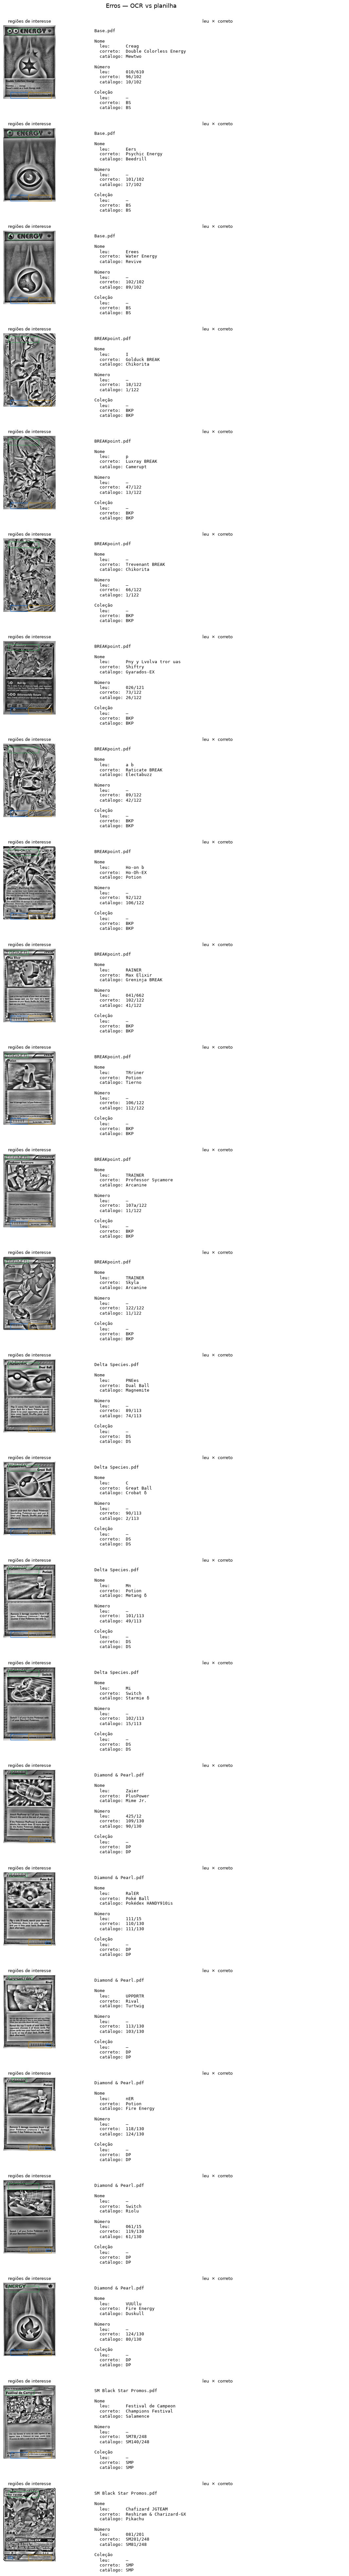

Figura: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pipeline_erros.png


,image,gt_name,gt_number,gt_set,ocr_name,ocr_number,ocr_collection,match_name,match_number,match_set
0,Base.pdf,Double Colorless Energy,96/102,BS,Creag,010/610,,Mewtwo,10/102,BS
1,Base.pdf,Psychic Energy,101/102,BS,Eers,,,Beedrill,17/102,BS
2,Base.pdf,Water Energy,102/102,BS,Erees,,,Revive,89/102,BS
3,BREAKpoint.pdf,Golduck BREAK,18/122,BKP,I,,,Chikorita,1/122,BKP
4,BREAKpoint.pdf,Luxray BREAK,47/122,BKP,p,,,Camerupt,13/122,BKP
5,BREAKpoint.pdf,Trevenant BREAK,66/122,BKP,,,,Chikorita,1/122,BKP
6,BREAKpoint.pdf,Shiftry,73/122,BKP,Pny y Lvolva tror uas,026/121,,Gyarados-EX,26/122,BKP
7,BREAKpoint.pdf,Raticate BREAK,89/122,BKP,a b,,,Electabuzz,42/122,BKP
8,BREAKpoint.pdf,Ho-Oh-EX,92/122,BKP,Ho-on b,,,Potion,106/122,BKP
9,BREAKpoint.pdf,Max Elixir,102/122,BKP,RAINER,041/662,,Greninja BREAK,41/122,BKP


In [33]:
ROI_STYLE = {
    "name": {"color": (46, 164, 79), "label": "name"},
    "number": {"color": (9, 105, 218), "label": "number"},
    "collection": {"color": (191, 135, 0), "label": "collection"},
}


def annotate_regions(bgr: np.ndarray, regions: dict) -> np.ndarray:
    vis = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).copy() if bgr.ndim == 3 else cv2.cvtColor(bgr, cv2.COLOR_GRAY2RGB)
    h, w = vis.shape[:2]
    thick = max(2, int(round(min(h, w) / 220)))
    for field, info in (regions or {}).items():
        style = ROI_STYLE.get(field)
        if style is None:
            continue
        quad = np.asarray(info["quad"], dtype=np.int32).reshape(-1, 2)
        cv2.polylines(vis, [quad], True, style["color"], thick, cv2.LINE_AA)
        x, y = int(quad[:, 0].min()), int(quad[:, 1].min())
        cv2.putText(
            vis,
            style["label"],
            (max(2, x), max(16, y - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            style["color"],
            1,
            cv2.LINE_AA,
        )
    return vis


def find_extract(row) -> dict | None:
    uid = str(row.get("uid", "") or "")
    if uid:
        for item in extracted:
            if item.get("uid") == uid:
                return item
    cands = [
        item
        for item in extracted
        if item["image"] == row["image"]
        and item["ocr_name"] == row["ocr_name"]
        and item["ocr_number"] == row["ocr_number"]
    ]
    return cands[0] if cands else None


def blank(text: str) -> str:
    text = "" if pd.isna(text) else str(text).strip()
    return text if text else "—"


def field_lines(row) -> str:
    name_note = ""
    if names_equivalent(row["gt_name"], row["match_name"]):
        name_note = "  (EN = PT)"
    return (
        f"{row['image']}\n\n"
        f"Name\n  read:     {blank(row['ocr_name'])}\n"
        f"  expected: {blank(row['gt_name'])}\n"
        f"  catalog:  {blank(row['match_name'])}{name_note}\n\n"
        f"Number\n  read:     {blank(row['ocr_number'])}\n"
        f"  expected: {blank(row['gt_number'])}\n"
        f"  catalog:  {blank(row['match_number'])}\n\n"
        f"Set\n  read:     {blank(row['ocr_collection'])}\n"
        f"  expected: {blank(row['gt_set'])}\n"
        f"  catalog:  {blank(row['match_set'])}"
    )


error_rows = gt_rows.loc[~gt_rows["id_ok"]].reset_index(drop=True) if "id_ok" in gt_rows.columns else pd.DataFrame()
if error_rows.empty:
    error_rows = eval_df[eval_df["gt_name"].astype(str).str.len() > 0].copy()
    error_rows = error_rows[
        [
            not pair_ok(
                {
                    "match_name": row["match_name"],
                    "match_number": row["match_number"],
                    "match_set": row["match_set"],
                    "ocr_name": row["ocr_name"],
                    "ocr_number": row["ocr_number"],
                    "ocr_collection": row["ocr_collection"],
                },
                pd.Series(
                    {
                        "name": row["gt_name"],
                        "number": row["gt_number"],
                        "collection": row["gt_set"],
                    }
                ),
            )
            for _, row in error_rows.iterrows()
        ]
    ].reset_index(drop=True)

n_err = len(error_rows)
print(f"{n_err} error(s) to review")
if n_err == 0:
    print("No errors under the PT/EN rule.")
else:
    fig, axes = plt.subplots(
        n_err,
        2,
        figsize=(12.8, 3.15 * n_err),
        gridspec_kw={"width_ratios": [1.05, 1.45]},
    )
    axes = np.atleast_2d(axes)
    for i, row in error_rows.iterrows():
        ax_img, ax_txt = axes[i, 0], axes[i, 1]
        item = find_extract(row)
        if item is not None:
            vis = annotate_regions(item["crop_bgr"], item.get("regions") or {})
            ax_img.imshow(vis)
        else:
            ax_img.set_facecolor("#f0f0f0")
            ax_img.text(0.5, 0.5, "no crop", ha="center", va="center", transform=ax_img.transAxes)
        ax_img.set_title("regions of interest", fontsize=9)
        ax_img.axis("off")
        ax_txt.text(
            0.02,
            0.96,
            field_lines(row),
            transform=ax_txt.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            family="monospace",
            linespacing=1.25,
        )
        ax_txt.set_title("read  vs  expected", fontsize=9)
        ax_txt.axis("off")
    fig.suptitle("Errors — OCR vs spreadsheet", fontsize=13, y=1.0)
    fig.tight_layout()
    err_path = OUT_DIR / "pipeline_erros.png"
    fig.savefig(err_path, dpi=130, bbox_inches="tight")
    plt.show()
    print("Figure:", err_path)
    display(error_rows[
        [
            "image",
            "gt_name",
            "gt_number",
            "gt_set",
            "ocr_name",
            "ocr_number",
            "ocr_collection",
            "match_name",
            "match_number",
            "match_set",
        ]
    ])
